# REINFORCE Continous Action Space)
이 튜토리얼은 연속적인 행동 공간(Continuous Action Space)에서의 **REINFORCE** 알고리즘을 구현하는 방법을 안내한다.

**REINFORCE**는 가장 기초적인 정책 경사(Policy Gradient) 알고리즘이다. 연속적인 행동 공간에서는 정책을 가우시안 분포(Gaussian Distribution)와 같은 확률 분포로 모델링하여, 평균()과 표준편차()를 학습한다.

이 튜토리얼에서는 최신 라이브러리인 `gymnasium`과 `torch`를 사용하여 구현하며, 환경은 `InvertedPendulum-v4` (Mujoco)를 사용한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치
# gymnasium[mujoco]: InvertedPendulum 환경 사용을 위해 필요
%pip install gymnasium[mujoco] pyvirtualdisplay torch numpy matplotlib imageio

In [11]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습 결과를 영상으로 확인하기 위한 함수다.

In [13]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. 정책 네트워크 생성 (Create the Policy)

연속 행동 공간에서는 행동의 확률 분포를 출력해야 한다. 여기서는 **가우시안 분포(Normal Distribution)**를 사용하여 행동을 샘플링한다.
네트워크는 상태를 입력받아 분포의 **평균(Mean, )**과 **표준편차(Scale, )**를 출력한다.

* **평균()**: `Tanh` 활성화 함수를 사용하여 범위를 조절할 수 있다.
* **표준편차()**: 항상 양수여야 하므로 `Softplus` 함수를 사용한다.

In [14]:
class GradientPolicy(nn.Module):
    def __init__(self, in_features, out_dims, hidden_size=128):
        """
        정책 네트워크 초기화
        :param in_features: 입력 상태의 차원
        :param out_dims: 출력 행동의 차원
        """
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)

        # 평균(Mean)을 예측하는 레이어
        self.fc_mu = nn.Linear(hidden_size, out_dims)
        # 표준편차(Standard Deviation)를 예측하는 레이어
        self.fc_std = nn.Linear(hidden_size, out_dims)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        # 평균값 계산
        loc = self.fc_mu(x)
        # loc = torch.tanh(loc) # 환경에 따라 Tanh 사용 여부 결정 (InvertedPendulum은 보통 필요 없음)

        # 표준편차 계산 (항상 양수여야 함)
        scale = self.fc_std(x)
        scale = F.softplus(scale) + 1e-3 # 0이 되는 것을 방지하기 위해 작은 값 더함

        return loc, scale

### 5. Pytorch Wrapper 클래스 (REINFORCE 구현)

REINFORCE 알고리즘의 핵심 로직을 담고 있는 클래스다.

1. **데이터 수집**: 에피소드가 끝날 때까지 행동을 선택하고 보상을 저장한다.
2. **반환값(Return) 계산**: 각 시점에서의 감가상각된 누적 보상(Discounted Return, )을 계산한다.
3. **정책 업데이트**: 손실 함수 를 최소화하는 방향으로 업데이트한다.

In [15]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=128, lr=1e-3, gamma=0.99):
        self.env_name = env_name
        self.gamma = gamma

        # 환경 생성
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        action_dim = self.env.action_space.shape[0]

        # 정책 네트워크 초기화
        self.policy = GradientPolicy(obs_size, action_dim, hidden_size).to(device)
        self.optimizer = optim.AdamW(self.policy.parameters(), lr=lr)

    def get_action(self, state):
        """
        상태를 입력받아 확률 분포 생성 후 행동 샘플링
        """
        state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)
        loc, scale = self.policy(state_t)

        # 가우시안 분포 생성
        dist = Normal(loc, scale)

        # 행동 샘플링
        action = dist.sample()

        # 로그 확률 계산 (학습 시 필요하므로 저장해둘 수도 있지만, 여기서는 바로 반환하지 않음)
        # REINFORCE는 에피소드 전체 데이터를 모은 후 다시 계산하는 방식이 구현하기 쉬움

        return action.cpu().numpy()[0]

    def calculate_returns(self, rewards):
        """
        감가상각된 누적 보상(Discounted Return) 계산
        """
        returns = []
        R = 0
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns, dtype=torch.float32, device=device)

        # 학습 안정화를 위한 정규화 (Mean 0, Std 1)
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        return returns

    def train_episode(self):
        """
        한 에피소드를 실행하고 정책을 업데이트함 (Monte-Carlo Update)
        """
        state, _ = self.env.reset()
        log_probs = []
        rewards = []

        # 1. 에피소드 진행 (데이터 수집)
        while True:
            state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)
            loc, scale = self.policy(state_t)
            dist = Normal(loc, scale)

            action = dist.sample()

            # 로그 확률 저장: log pi(a|s)
            log_prob = dist.log_prob(action).sum(dim=-1)
            log_probs.append(log_prob)

            # 환경 상호작용
            action_np = action.cpu().numpy()[0]
            next_state, reward, terminated, truncated, _ = self.env.step(action_np)
            done = terminated or truncated

            rewards.append(reward)
            state = next_state

            if done:
                break

        # 2. 반환값(Return) 계산
        returns = self.calculate_returns(rewards)

        # 3. 정책 손실 계산 (Policy Loss)
        # Loss = - sum( log_prob * return )
        log_probs = torch.stack(log_probs)
        loss = -(log_probs * returns).sum()

        # 4. 역전파 및 업데이트
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return sum(rewards) # 에피소드 총 보상 반환

    def run_training(self, max_episodes=1000, print_interval=200):
        total_rewards = []

        for episode in range(max_episodes):
            episode_reward = self.train_episode()
            total_rewards.append(episode_reward)

            if episode % print_interval == 0:
                print(f"Episode {episode}, Reward: {episode_reward:.2f}")

        return total_rewards

    def save_video(self, filename="reinforce_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False

        while not done:
            # 테스트 시에는 평균값(loc)을 행동으로 사용할 수도 있고, 샘플링할 수도 있음
            # 여기서는 샘플링 사용
            action = self.get_action(state)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()

### 6. 학습 실행 (Training)

REINFORCE 에이전트를 생성하고 `InvertedPendulum-v4` 환경에서 학습을 시작한다. 이 환경은 막대기가 넘어지지 않도록 균형을 잡는 것이 목표다.

In [16]:
# 모델 생성
# InvertedPendulum-v4는 Mujoco 환경임. (없다면 Pendulum-v1 등으로 대체 가능)
agent = PytorchWrapper(
    'InvertedPendulum-v4',
    hidden_size=128,
    lr=1e-3,
    gamma=0.99
)

# 학습 시작
print("REINFORCE (Continuous) 학습을 시작한다...")
history = agent.run_training(max_episodes=1000)
print("학습 완료.")

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


REINFORCE (Continuous) 학습을 시작한다...
Episode 0, Reward: 11.00
Episode 200, Reward: 3.00
Episode 400, Reward: 5.00
Episode 600, Reward: 3.00
Episode 800, Reward: 3.00
학습 완료.


### 7. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다. REINFORCE는 학습 분산이 크기 때문에 보상 그래프가 진동할 수 있다.

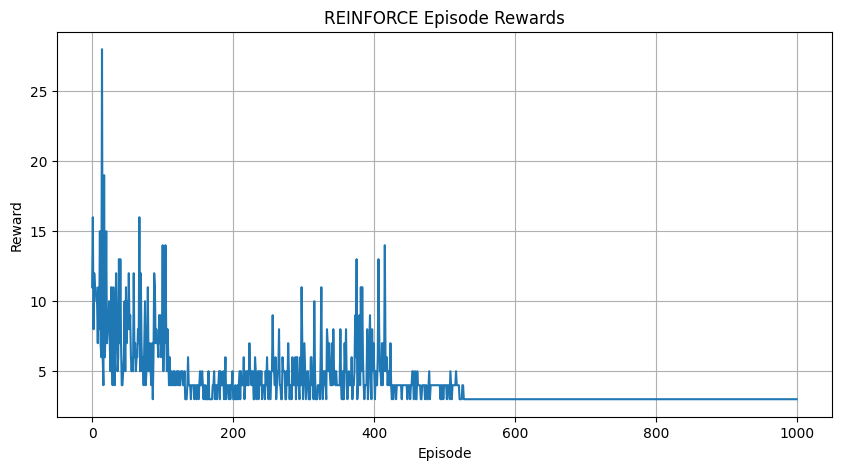

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [17]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("REINFORCE Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("reinforce")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")